In [ ]:
!pip install xgboost lightgbm imbalanced-learn scikit-learn -q


In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform, randint, uniform

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score, cross_validate, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, fbeta_score,
    recall_score, precision_score, f1_score,
    precision_recall_curve, average_precision_score, roc_auc_score,
    matthews_corrcoef, make_scorer
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving X_test.csv to X_test.csv
Saving X_train.csv to X_train.csv
Saving y_test.csv to y_test.csv
Saving y_train.csv to y_train.csv


In [ ]:
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train_full = pd.read_csv('y_train.csv')
y_test_full  = pd.read_csv('y_test.csv')

# 4. Fokus ke target utama: machine_failure
# (twf/hdf/pwf/osf/rnf disimpan terpisah, kasusnya terlalu sedikit untuk dimodelkan individual)
y_train = y_train_full['machine_failure']
y_test  = y_test_full['machine_failure']

# 5. Cek shape dan distribusi
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

print("\nDistribusi target (train):")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("\nDistribusi target (test):")
print(y_test.value_counts(normalize=True).round(4) * 100)

X_train: (8000, 9) | X_test: (2000, 9)

Distribusi target (train):
machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64

Distribusi target (test):
machine_failure
0    96.6
1     3.4
Name: proportion, dtype: float64


## **Screnning Lazypredit**

In [ ]:
!pip install -U lazypredict==0.3.0 -q

from lazypredict.Supervised import LazyClassifier
from sklearn.metrics import recall_score

# LazyPredict pakai data mentah (dia bikin pipeline scaling sendiri per model)
lazy_clf = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=recall_score
)

screening_results, screening_predictions = lazy_clf.fit(X_train, X_test, y_train, y_test)

screening_results = screening_results.sort_values('Recall', ascending=False)
display(screening_results.head(10))

# Lihat model teratas hasil screening -> jadi acuan model mana yang diprioritaskan.
print("Model dengan Recall tertinggi dari screening:")
print(screening_results.head(5).index.tolist())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.5 MB/s eta 0:00:00


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,recall_score,Time Taken
Model,,,,,,,,
LGBMClassifier,0.9930,0.911247,0.981854,0.992731,0.992858,0.9930,0.823529,0.313108
RandomForestClassifier,0.9925,0.903894,0.975684,0.992181,0.992344,0.9925,0.808824,1.574973
XGBClassifier,0.9915,0.903377,0.984350,0.991209,0.991225,0.9915,0.808824,1.227360
BaggingClassifier,0.9915,0.896282,0.958935,0.991138,0.991250,0.9915,0.794118,0.412581
DecisionTreeClassifier,0.9870,0.901047,0.901047,0.987000,0.987000,0.9870,0.808824,0.100355
ExtraTreesClassifier,0.9855,0.815141,0.967167,0.984215,0.984741,0.9855,0.632353,0.488910
SVC,0.9770,0.690141,0.974409,0.972653,0.974872,0.9770,0.382353,0.501546
AdaBoostClassifier,0.9765,0.682788,0.962212,0.971893,0.974236,0.9765,0.367647,0.708922
KNeighborsClassifier,0.9745,0.653377,0.881017,0.968745,0.971572,0.9745,0.308824,0.108600


Model dengan Recall tertinggi dari screening:
['LGBMClassifier', 'RandomForestClassifier', 'XGBClassifier', 'BaggingClassifier', 'DecisionTreeClassifier']


## Arsitektur Pipeline: Train / Validation / Test


In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.3, stratify=y_train, random_state=RANDOM_STATE
)

print("X_tr :", X_tr.shape, " | positif:", y_tr.sum(), f"({y_tr.mean()*100:.2f}%)")
print("X_val:", X_val.shape, " | positif:", y_val.sum(), f"({y_val.mean()*100:.2f}%)")

# Scaler untuk fase tuning
scaler_tr = StandardScaler()
X_tr_scaled  = pd.DataFrame(scaler_tr.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
X_val_scaled = pd.DataFrame(scaler_tr.transform(X_val), columns=X_val.columns, index=X_val.index)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f2_scorer = make_scorer(fbeta_score, beta=2)

scale_pos_weight_tr = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"\nscale_pos_weight (dihitung dari y_tr) = {scale_pos_weight_tr:.2f}")


X_tr : (5600, 9)  | positif: 190 (3.39%)
X_val: (2400, 9)  | positif: 81 (3.38%)

scale_pos_weight (dihitung dari y_tr) = 28.47


In [ ]:
def evaluate_model(name, y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results = {
        'model': name,
        'recall': round(recall_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred), 4),
        'f1': round(f1_score(y_true, y_pred), 4),
        'f2': round(fbeta_score(y_true, y_pred, beta=2), 4),
        'mcc': round(matthews_corrcoef(y_true, y_pred), 4),
        'pr_auc': round(average_precision_score(y_true, y_proba), 4),
        'roc_auc': round(roc_auc_score(y_true, y_proba), 4),
        'confusion_matrix': {'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)},
    }
    print(f"--- {name} ---")
    for k, v in results.items():
        if k not in ('model', 'confusion_matrix'):
            print(f"  {k:<10}: {v}")
    print(f"  confusion  : TN={tn} FP={fp} FN={fn} TP={tp}")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Failure']))
    return results

def plot_confusion(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


## Hyperparameter Tuning — SEMUA model (poin #3 & #4)
Tiap model di-tuning dengan `RandomizedSearchCV`, yang di dalamnya sudah otomatis pakai `cv=StratifiedKFold(5)` di `X_tr` — jadi tiap kombinasi parameter dievaluasi lewat cross-validation,


In [ ]:
param_grids = {
    'Logistic Regression': {
        'estimator': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE),
        'param_dist': {
            'C': loguniform(1e-3, 15.0),               # DIPERKETAT: batas atas diturunkan dari 30 -> 15
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear'],
        },
        'use_scaled': True,
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1),
        'param_dist': {
            'n_estimators': randint(300, 700),
            'max_depth': [4, 6, 8, 10, 12],
            'min_samples_leaf': randint(4, 20),
            'min_samples_split': randint(8, 35),
            'max_features': ['sqrt', 'log2'],
            'max_samples': uniform(0.5, 0.4),
            'ccp_alpha': uniform(0.0, 0.04),
        },
        'use_scaled': False,
    },
    'XGBoost': {
        'estimator': XGBClassifier(scale_pos_weight=scale_pos_weight_tr, eval_metric='aucpr',
                                    random_state=RANDOM_STATE, n_jobs=-1),
        'param_dist': {
            'n_estimators': randint(100, 350),          # DIPERKETAT: batas atas turun dari 500 -> 350
            'max_depth': randint(3, 6),                 # DIPERKETAT: batas atas turun dari 8 -> 6
            'learning_rate': loguniform(0.01, 0.15),
            'subsample': uniform(0.5, 0.3),             # DIPERKETAT: geser ke 0.5-0.8
            'colsample_bytree': uniform(0.5, 0.3),      # DIPERKETAT: geser ke 0.5-0.8
            'colsample_bylevel': uniform(0.5, 0.3),     # BARU: regularisasi tambahan per level tree
            'min_child_weight': randint(4, 20),         # DIPERKETAT: minimum naik dari 2 -> 4
            'gamma': uniform(0.5, 5.5),                 # DIPERKETAT: minimum naik dari 0.2 -> 0.5
            'reg_alpha': loguniform(0.5, 25.0),         # DIPERKETAT: minimum naik dari 0.05 -> 0.5
            'reg_lambda': loguniform(0.5, 25.0),        # DIPERKETAT: minimum naik dari 0.05 -> 0.5
        },
        'use_scaled': False,
    },
    'LightGBM': {
        'estimator': LGBMClassifier(scale_pos_weight=scale_pos_weight_tr, random_state=RANDOM_STATE,
                                     n_jobs=-1, verbose=-1),
        'param_dist': {
            'n_estimators': randint(100, 350),          # DIPERKETAT
            'max_depth': randint(3, 6),                 # DIPERKETAT
            'num_leaves': randint(8, 35),                # DIPERKETAT: batas atas turun dari 60 -> 35
            'learning_rate': loguniform(0.01, 0.15),
            'subsample': uniform(0.5, 0.3),
            'colsample_bytree': uniform(0.5, 0.3),
            'min_child_samples': randint(20, 90),        # DIPERKETAT: minimum naik dari 10 -> 20
            'reg_alpha': loguniform(0.5, 25.0),
            'reg_lambda': loguniform(0.5, 25.0),
        },
        'use_scaled': False,
    },
}

tuned_models = {}   # simpan best_estimator_ per model
tuning_log = []      # simpan info CV score per model, untuk bukti semua sudah lewat CV

for name, cfg in param_grids.items():
    print(f"\n=== Tuning {name} ===")
    X_fit = X_tr_scaled if cfg['use_scaled'] else X_tr

    search = RandomizedSearchCV(
        estimator=cfg['estimator'],
        param_distributions=cfg['param_dist'],
        n_iter=30,
        scoring=f2_scorer,
        cv=cv,                # <- cross-validation di sini, untuk SEMUA model
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_fit, y_tr)

    tuned_models[name] = {
        'estimator': search.best_estimator_,
        'params': search.best_params_,
        'use_scaled': cfg['use_scaled'],
    }
    tuning_log.append({
        'model': name,
        'cv_f2_mean': round(search.best_score_, 4),
        'cv_f2_std': round(search.cv_results_['std_test_score'][search.best_index_], 4),
        'best_params': search.best_params_,
    })
    print(f"Best CV F2: {search.best_score_:.4f} (+/- {search.cv_results_['std_test_score'][search.best_index_]:.4f})")
    print(f"Best params: {search.best_params_}")

tuning_log_df = pd.DataFrame(tuning_log).set_index('model')[['cv_f2_mean', 'cv_f2_std']]
print("\n=== Ringkasan CV F2-score tiap model (bukti semua sudah lewat cross-validation) ===")
display(tuning_log_df)



=== Tuning Logistic Regression ===
Best CV F2: 0.4869 (+/- 0.0169)
Best params: {'C': np.float64(0.34447899504818147), 'penalty': 'l1', 'solver': 'liblinear'}

=== Tuning Random Forest ===
Best CV F2: 0.7677 (+/- 0.0159)
Best params: {'ccp_alpha': np.float64(0.009875042513544048), 'max_depth': 6, 'max_features': 'sqrt', 'max_samples': np.float64(0.6203513239267079), 'min_samples_leaf': 4, 'min_samples_split': 31, 'n_estimators': 380}

=== Tuning XGBoost ===
Best CV F2: 0.8171 (+/- 0.0272)
Best params: {'colsample_bylevel': np.float64(0.7087353198035247), 'colsample_bytree': np.float64(0.5685650065391898), 'gamma': np.float64(1.462252099027649), 'learning_rate': np.float64(0.1429287526185321), 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 228, 'reg_alpha': np.float64(0.7196955446635454), 'reg_lambda': np.float64(16.722941268711974), 'subsample': np.float64(0.7701254171489991)}

=== Tuning LightGBM ===
Best CV F2: 0.8567 (+/- 0.0342)
Best params: {'colsample_bytree': np.float64

,cv_f2_mean,cv_f2_std
model,,
Logistic Regression,0.4869,0.0169
Random Forest,0.7677,0.0159
XGBoost,0.8171,0.0272
LightGBM,0.8567,0.0342


### (Alternatif, opsional) Tuning salah satu model pakai Optuna
coba Optuna untuk salah satu kandidat (misal XGBoost) sebagai pembanding terhadap hasil `RandomizedSearchCV` di atas bisa pakai pola ini. Cukup ganti isi `tuned_models['XGBoost']` kalau hasil Optuna lebih baik dari CV F2-nya.


In [ ]:
!pip install optuna -q

import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 600, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }
    model = XGBClassifier(**params, scale_pos_weight=scale_pos_weight_tr,
                           eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1)
    return cross_val_score(model, X_tr, y_tr, cv=cv, scoring=f2_scorer, n_jobs=-1).mean()

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best CV F2 (Optuna):", round(study.best_value, 4))
print("vs RandomizedSearchCV:", tuning_log_df.loc['XGBoost', 'cv_f2_mean'])

# Kalau Optuna menang, timpa hasil RandomizedSearchCV untuk XGBoost:
if study.best_value > tuning_log_df.loc['XGBoost', 'cv_f2_mean']:
    best_xgb = XGBClassifier(**study.best_params, scale_pos_weight=scale_pos_weight_tr,
                              eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1)
    best_xgb.fit(X_tr, y_tr)
    tuned_models['XGBoost'] = {'estimator': best_xgb, 'params': study.best_params, 'use_scaled': False}
    print("XGBoost diganti dengan hasil Optuna (lebih baik).")
else:
    print("RandomizedSearchCV masih lebih baik/setara, XGBoost tidak diganti.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 28.2 MB/s eta 0:00:00


  0%|          | 0/50 [00:00<?, ?it/s]

Best CV F2 (Optuna): 0.8537
vs RandomizedSearchCV: 0.8477
XGBoost diganti dengan hasil Optuna (lebih baik).


## Model Selection — evaluasi di `X_val` (poin #1)
Ini kali pertama ke-4 model yang sudah di-tuning diuji di data yang benar-benar belum pernah mereka lihat (`X_val`). `X_test` masih belum disentuh sama sekali.


--- Logistic Regression @ threshold=0.8135 ---
  recall    : 0.6049
  precision : 0.3006
  f1        : 0.4016
  f2        : 0.5031
  mcc       : 0.3989
  pr_auc    : 0.4116
  roc_auc   : 0.9083
  confusion  : TN=2205 FP=114 FN=32 TP=49
              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97      2319
     Failure       0.30      0.60      0.40        81

    accuracy                           0.94      2400
   macro avg       0.64      0.78      0.68      2400
weighted avg       0.96      0.94      0.95      2400

--- Random Forest @ threshold=0.4413 ---
  recall    : 0.9136
  precision : 0.3008
  f1        : 0.4526
  f2        : 0.6491
  mcc       : 0.4998
  pr_auc    : 0.7975
  roc_auc   : 0.9794
  confusion  : TN=2147 FP=172 FN=7 TP=74
              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96      2319
     Failure       0.30      0.91      0.45        81

    accuracy                           0.93 

,recall,precision,f1,f2,mcc,threshold
model,,,,,,
Random Forest,0.9136,0.3008,0.4526,0.6491,0.4998,0.4413
LightGBM,0.9136,0.3008,0.4526,0.6491,0.4998,0.0689
XGBoost,0.8889,0.3000,0.4486,0.6383,0.4915,0.1544
Logistic Regression,0.6049,0.3006,0.4016,0.5031,0.3989,0.8135


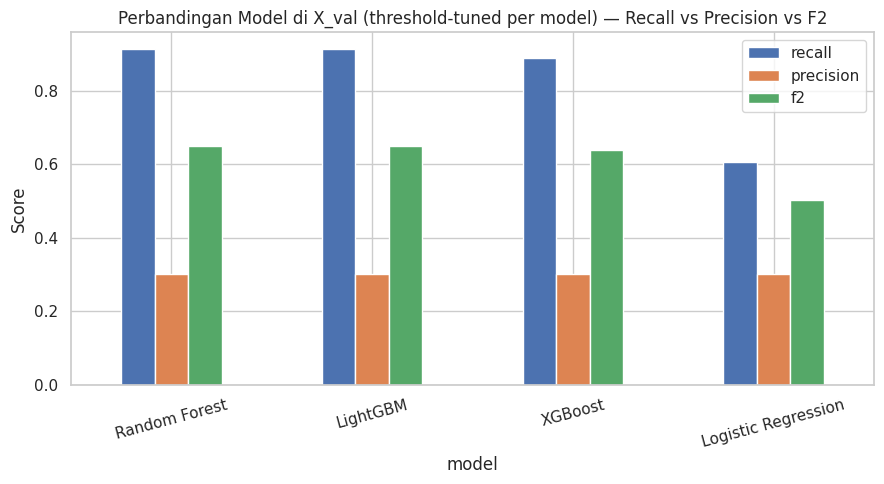

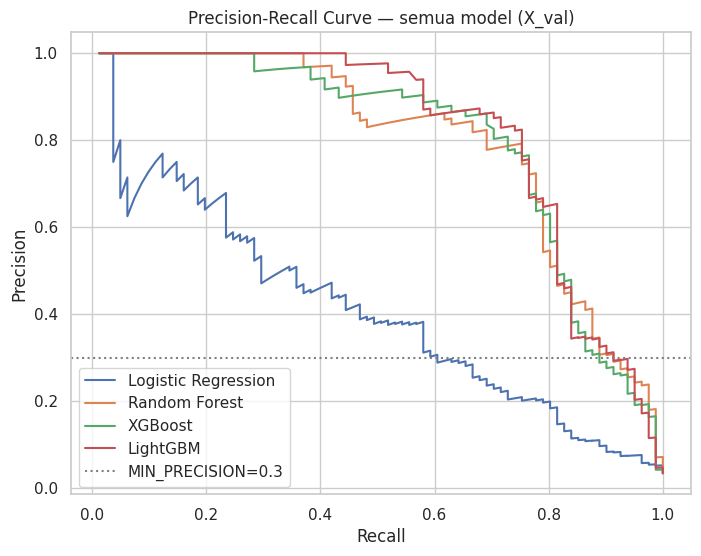

In [ ]:
MIN_PRECISION = 0.3  # TODO: sesuaikan kebutuhan

def find_best_threshold(y_true, y_proba, min_precision):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    valid_idx = np.where(precisions[:-1] >= min_precision)[0]
    if len(valid_idx) > 0:
        best_idx = valid_idx[np.argmax(recalls[:-1][valid_idx])]
        return thresholds[best_idx], precisions, recalls, thresholds
    return 0.5, precisions, recalls, thresholds

val_results = []
val_thresholds = {}
val_curves = {}

for name, info in tuned_models.items():
    model = info['estimator']
    X_eval = X_val_scaled if info['use_scaled'] else X_val
    y_proba = model.predict_proba(X_eval)[:, 1]

    thr, precisions, recalls, thresholds = find_best_threshold(y_val, y_proba, MIN_PRECISION)
    y_pred = (y_proba >= thr).astype(int)

    res = evaluate_model(f"{name} @ threshold={thr:.4f}", y_val, y_pred, y_proba)
    res['model'] = name  # kembalikan ke nama polos supaya cocok dengan key tuned_models
    res['threshold'] = round(float(thr), 4)
    val_thresholds[name] = thr
    val_curves[name] = (precisions, recalls, thresholds)
    val_results.append(res)

val_comparison_df = pd.DataFrame(val_results).drop(columns=['confusion_matrix']).set_index('model')
val_comparison_df = val_comparison_df.sort_values('f2', ascending=False)

print("=== Perbandingan model di X_val, MASING-MASING di threshold terbaiknya (urut Recall) ===")
display(val_comparison_df[['recall', 'precision', 'f1', 'f2', 'mcc', 'threshold']])

val_comparison_df[['recall', 'precision', 'f2']].plot(kind='bar', figsize=(9, 5))
plt.title('Perbandingan Model di X_val (threshold-tuned per model) — Recall vs Precision vs F2')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Overlay precision-recall curve semua model, buat lihat kandidat mana yg kurva-nya lebih baik
plt.figure(figsize=(8, 6))
for name, (precisions, recalls, thresholds) in val_curves.items():
    plt.plot(recalls[:-1], precisions[:-1], label=name)
plt.axhline(MIN_PRECISION, color='gray', linestyle=':', label=f'MIN_PRECISION={MIN_PRECISION}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — semua model (X_val)')
plt.legend()
plt.show()


In [ ]:
# Model dengan Recall tertinggi (di threshold terbaiknya masing-masing) dipilih sebagai pemenang
winner_name = val_comparison_df.index[0]
winner_info = tuned_models[winner_name]
winner_model_val = winner_info['estimator']   # model ini masih dilatih di X_tr saja
best_threshold = val_thresholds[winner_name]   # threshold ini langsung dipakai, tidak perlu dicari ulang

print(f"Model terpilih: {winner_name}")
print(f"Hyperparameter terbaik: {winner_info['params']}")
print(f"Recall di X_val (threshold={best_threshold:.4f}): {val_comparison_df.loc[winner_name, 'recall']}")
print(f"Precision di X_val (threshold={best_threshold:.4f}): {val_comparison_df.loc[winner_name, 'precision']}")


Model terpilih: Random Forest
Hyperparameter terbaik: {'ccp_alpha': np.float64(0.009875042513544048), 'max_depth': 6, 'max_features': 'sqrt', 'max_samples': np.float64(0.6203513239267079), 'min_samples_leaf': 4, 'min_samples_split': 31, 'n_estimators': 380}
Recall di X_val (threshold=0.4413): 0.9136
Precision di X_val (threshold=0.4413): 0.3008


## Perdalam Tuning Model Pemenang dengan Optuna

In [ ]:
!pip install optuna -q

import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

X_fit_winner = X_tr_scaled if winner_info['use_scaled'] else X_tr

def build_model(trial, model_name):
    if model_name == 'Logistic Regression':
        params = {
            'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
            'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        }
        return LogisticRegression(**params, solver='liblinear', class_weight='balanced',
                                   max_iter=2000, random_state=RANDOM_STATE)
    elif model_name == 'Random Forest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 700, step=50),
            'max_depth': trial.suggest_categorical('max_depth', [None, 5, 8, 10, 15, 20, 25]),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        }
        return RandomForestClassifier(**params, class_weight='balanced_subsample',
                                       random_state=RANDOM_STATE, n_jobs=-1)
    elif model_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 150, 700, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        }
        return XGBClassifier(**params, scale_pos_weight=scale_pos_weight_tr, eval_metric='aucpr',
                              random_state=RANDOM_STATE, n_jobs=-1)
    elif model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 150, 700, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'num_leaves': trial.suggest_int('num_leaves', 15, 100),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        }
        return LGBMClassifier(**params, scale_pos_weight=scale_pos_weight_tr,
                               random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

def objective(trial):
    model = build_model(trial, winner_name)
    return cross_val_score(model, X_fit_winner, y_tr, cv=cv, scoring=f2_scorer, n_jobs=-1).mean()

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=True)

prev_cv_f2 = tuning_log_df.loc[winner_name, 'cv_f2_mean']
print(f"Best CV F2 (Optuna) untuk {winner_name}: {study.best_value:.4f}")
print(f"CV F2 dari RandomizedSearchCV sebelumnya: {prev_cv_f2:.4f}")

if study.best_value > prev_cv_f2:
    print("Optuna menemukan hasil lebih baik -> model pemenang & threshold di-update.")
    winner_info['params'] = study.best_params
    winner_model_val = build_model(optuna.trial.FixedTrial(study.best_params), winner_name)
    winner_model_val.fit(X_fit_winner, y_tr)
    tuned_models[winner_name]['estimator'] = winner_model_val
    tuned_models[winner_name]['params'] = study.best_params

    # Threshold WAJIB dicari ulang -> probabilitas model sudah berubah
    X_val_eval = X_val_scaled if winner_info['use_scaled'] else X_val
    y_proba_val_new = winner_model_val.predict_proba(X_val_eval)[:, 1]
    best_threshold, _, _, _ = find_best_threshold(y_val, y_proba_val_new, MIN_PRECISION)
    y_pred_val_new = (y_proba_val_new >= best_threshold).astype(int)
    print(f"Threshold baru: {best_threshold:.4f}")
    evaluate_model(f"{winner_name} (setelah Optuna) @ X_val", y_val, y_pred_val_new, y_proba_val_new)
else:
    print("RandomizedSearchCV masih lebih baik/setara -> model pemenang & threshold TIDAK diganti.")


  0%|          | 0/50 [00:00<?, ?it/s]

Best CV F2 (Optuna) untuk Random Forest: 0.8684
CV F2 dari RandomizedSearchCV sebelumnya: 0.7677
Optuna menemukan hasil lebih baik -> model pemenang & threshold di-update.
Threshold baru: 0.1067
--- Random Forest (setelah Optuna) @ X_val ---
  recall    : 0.8889
  precision : 0.3
  f1        : 0.4486
  f2        : 0.6383
  mcc       : 0.4915
  pr_auc    : 0.8292
  roc_auc   : 0.9769
  confusion  : TN=2151 FP=168 FN=9 TP=72
              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96      2319
     Failure       0.30      0.89      0.45        81

    accuracy                           0.93      2400
   macro avg       0.65      0.91      0.70      2400
weighted avg       0.97      0.93      0.94      2400



## Retrain di seluruh `X_train`, Evaluasi Final — `X_test` disentuh TEPAT SEKALI (poin #2)
Model pemenang dilatih ulang dari nol dengan hyperparameter terbaiknya, kali ini di **seluruh `X_train`** (gabungan `X_tr` + `X_val`), lalu diuji satu kali di `X_test`.


--- Random Forest (final, retrained on full X_train) ---
  recall    : 0.9412
  precision : 0.3787
  f1        : 0.5401
  f2        : 0.7256
  mcc       : 0.5778
  pr_auc    : 0.8903
  roc_auc   : 0.9688
  confusion  : TN=1827 FP=105 FN=4 TP=64
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97      1932
     Failure       0.38      0.94      0.54        68

    accuracy                           0.95      2000
   macro avg       0.69      0.94      0.76      2000
weighted avg       0.98      0.95      0.96      2000



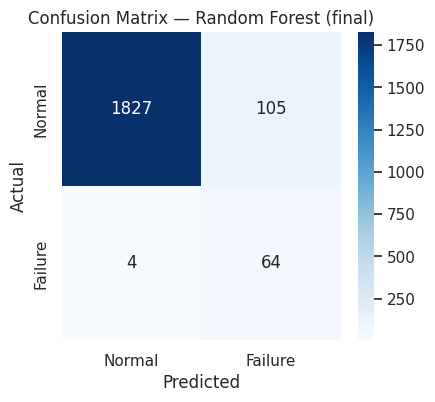

In [ ]:
# Scaler baru, fit di SELURUH X_train (dipakai kalau model pemenang butuh scaling, mis. LogReg)
scaler_full = StandardScaler()
X_train_scaled_full = pd.DataFrame(scaler_full.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled_full  = pd.DataFrame(scaler_full.transform(X_test), columns=X_test.columns, index=X_test.index)

# scale_pos_weight dihitung ulang dari seluruh y_train untuk model final
scale_pos_weight_full = (y_train == 0).sum() / (y_train == 1).sum()

# Bangun ulang model pemenang dengan hyperparameter terbaiknya, fresh instance
best_params = winner_info['params']
model_constructors = {
    'Logistic Regression': lambda: LogisticRegression(**best_params, class_weight='balanced',
                                                         max_iter=2000, random_state=RANDOM_STATE),
    'Random Forest': lambda: RandomForestClassifier(**best_params, class_weight='balanced_subsample',
                                                       random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': lambda: XGBClassifier(**best_params, scale_pos_weight=scale_pos_weight_full,
                                       eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1),
    'LightGBM': lambda: LGBMClassifier(**best_params, scale_pos_weight=scale_pos_weight_full,
                                         random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

best_model = model_constructors[winner_name]()

if winner_info['use_scaled']:
    best_model.fit(X_train_scaled_full, y_train)
    y_proba_best = best_model.predict_proba(X_test_scaled_full)[:, 1]
else:
    best_model.fit(X_train, y_train)
    y_proba_best = best_model.predict_proba(X_test)[:, 1]

y_pred_final = (y_proba_best >= best_threshold).astype(int)

final_results = evaluate_model(f'{winner_name} (final, retrained on full X_train)', y_test, y_pred_final, y_proba_best)
final_results['threshold'] = round(float(best_threshold), 4)
final_results['best_params'] = best_params
final_results['model_name'] = winner_name
plot_confusion(f'{winner_name} (final)', y_test, y_pred_final)


## Cek Overfitting — bandingkan performa di `X_train` vs `X_test`
Kalau model overfitting, performanya akan terlihat jauh lebih bagus di data yang dia lihat sendiri saat training (`X_train`) dibanding di data yang benar-benar baru (`X_test`). Gap besar di sini = sinyal overfitting.

In [ ]:
X_train_eval = X_train_scaled_full if winner_info['use_scaled'] else X_train
y_proba_train = best_model.predict_proba(X_train_eval)[:, 1]
y_pred_train = (y_proba_train >= best_threshold).astype(int)

train_results = evaluate_model(f'{winner_name} (dievaluasi di X_train sendiri)', y_train, y_pred_train, y_proba_train)

metric_keys = ['recall', 'precision', 'f1', 'f2', 'mcc', 'pr_auc', 'roc_auc']
overfit_check = pd.DataFrame({
    'Train': {k: train_results[k] for k in metric_keys},
    'Test':  {k: final_results[k] for k in metric_keys},
})
overfit_check['Gap (Train - Test)'] = (overfit_check['Train'] - overfit_check['Test']).round(4)
display(overfit_check)

print("Panduan cepat baca gap:")
print("- Gap < 0.05-0.10 di sebagian besar metrik -> generalisasi model cukup baik, overfitting minor/wajar.")
print("- Gap > 0.15-0.20, apalagi Train jauh lebih tinggi dari Test -> indikasi overfitting, pertimbangkan regularisasi lebih kuat")
print("  (turunkan max_depth/n_estimators, naikkan reg_alpha/reg_lambda/min_child_samples/ccp_alpha di param_grids Cell tuning).")


--- Random Forest (dievaluasi di X_train sendiri) ---
  recall    : 1.0
  precision : 0.4532
  f1        : 0.6237
  f2        : 0.8056
  mcc       : 0.6588
  pr_auc    : 0.9942
  roc_auc   : 0.9998
  confusion  : TN=7402 FP=327 FN=0 TP=271
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98      7729
     Failure       0.45      1.00      0.62       271

    accuracy                           0.96      8000
   macro avg       0.73      0.98      0.80      8000
weighted avg       0.98      0.96      0.97      8000



,Train,Test,Gap (Train - Test)
recall,1.0000,0.9412,0.0588
precision,0.4532,0.3787,0.0745
f1,0.6237,0.5401,0.0836
f2,0.8056,0.7256,0.0800
mcc,0.6588,0.5778,0.0810
pr_auc,0.9942,0.8903,0.1039
roc_auc,0.9998,0.9688,0.0310


Panduan cepat baca gap:
- Gap < 0.05-0.10 di sebagian besar metrik -> generalisasi model cukup baik, overfitting minor/wajar.
- Gap > 0.15-0.20, apalagi Train jauh lebih tinggi dari Test -> indikasi overfitting, pertimbangkan regularisasi lebih kuat
  (turunkan max_depth/n_estimators, naikkan reg_alpha/reg_lambda/min_child_samples/ccp_alpha di param_grids Cell tuning).


## Triangulasi: CV (X_tr) vs Val (X_val) vs Test (X_test)
Train-vs-Test saja bisa menyesatkan (Train dievaluasi di data yang sama persis dengan yang dipakai fit). Perbandingan yang lebih jujur: **CV score out-of-fold saat tuning** (model tidak pernah lihat fold itu saat dilatih), **skor di X_val**, dan **skor di X_test** — tiga angka independen. Kalau ketiganya berdekatan, itu bukti generalisasi bagus jauh lebih kuat daripada sekadar Train vs Test.


In [ ]:
mcc_scorer = make_scorer(matthews_corrcoef)
scoring_dict = {'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'f2': f2_scorer, 'mcc': mcc_scorer}

X_cv_eval = X_tr_scaled if winner_info['use_scaled'] else X_tr
cv_scores = cross_validate(winner_model_val, X_cv_eval, y_tr, cv=cv, scoring=scoring_dict, n_jobs=-1)

cv_row = {
    'recall': round(cv_scores['test_recall'].mean(), 4),
    'precision': round(cv_scores['test_precision'].mean(), 4),
    'f1': round(cv_scores['test_f1'].mean(), 4),
    'f2': round(cv_scores['test_f2'].mean(), 4),
    'mcc': round(cv_scores['test_mcc'].mean(), 4),
}
val_row = {k: val_comparison_df.loc[winner_name, k] for k in ['recall', 'precision', 'f1', 'f2', 'mcc']}
test_row = {k: final_results[k] for k in ['recall', 'precision', 'f1', 'f2', 'mcc']}

triangulation_df = pd.DataFrame({
    'CV (X_tr, out-of-fold)': cv_row,
    'Val (X_val)': val_row,
    'Test (X_test)': test_row,
})
triangulation_df['Max gap'] = (triangulation_df.max(axis=1) - triangulation_df.min(axis=1)).round(4)
display(triangulation_df)

print("Panduan cepat:")
print("- Ketiga kolom berdekatan (gap kecil) di semua metrik -> generalisasi solid, overfitting kemungkinan kecil.")
print("- CV/Val jauh lebih tinggi dari Test -> waspada, model mungkin overfit ke X_tr/X_val atau ada distribution shift di X_test.")


,"CV (X_tr, out-of-fold)",Val (X_val),Test (X_test),Max gap
recall,0.8684,0.9136,0.9412,0.0728
precision,0.8710,0.3008,0.3787,0.5702
f1,0.8689,0.4526,0.5401,0.4163
f2,0.8684,0.6491,0.7256,0.2193
mcc,0.8647,0.4998,0.5778,0.3649


Panduan cepat:
- Ketiga kolom berdekatan (gap kecil) di semua metrik -> generalisasi solid, overfitting kemungkinan kecil.
- CV/Val jauh lebih tinggi dari Test -> waspada, model mungkin overfit ke X_tr/X_val atau ada distribution shift di X_test.


## Learning Curve — Train vs Validation score seiring jumlah data
Cara paling visual untuk membedakan overfitting (variance tinggi) vs underfitting (bias tinggi): lihat bagaimana skor Train dan Validation berubah seiring jumlah data training bertambah.


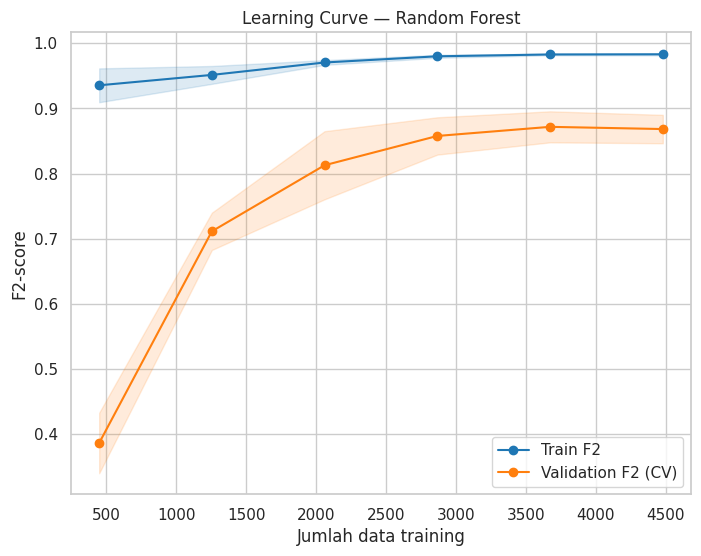

Cara baca:
- Train tinggi & Validation jauh di bawah, gap TIDAK menyempit walau data ditambah -> overfitting (variance tinggi).
  Solusi: perkuat regularisasi (turunkan max_depth/n_estimators, naikkan reg_alpha/reg_lambda), atau tambah data.
- Train & Validation sama-sama rendah dan konvergen -> underfitting (bias tinggi). Solusi: model lebih kompleks/fitur baru.
- Train & Validation konvergen di skor tinggi, gap kecil -> good fit.


In [ ]:
from sklearn.model_selection import learning_curve

def build_winner_fresh(scale_pos_weight_value):
    p = winner_info['params']
    if winner_name == 'Logistic Regression':
        return LogisticRegression(**p, class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
    elif winner_name == 'Random Forest':
        return RandomForestClassifier(**p, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)
    elif winner_name == 'XGBoost':
        return XGBClassifier(**p, scale_pos_weight=scale_pos_weight_value, eval_metric='aucpr',
                              random_state=RANDOM_STATE, n_jobs=-1)
    elif winner_name == 'LightGBM':
        return LGBMClassifier(**p, scale_pos_weight=scale_pos_weight_value, random_state=RANDOM_STATE,
                               n_jobs=-1, verbose=-1)

X_lc = X_tr_scaled if winner_info['use_scaled'] else X_tr

train_sizes, train_scores, val_scores = learning_curve(
    build_winner_fresh(scale_pos_weight_tr),
    X_lc, y_tr,
    cv=cv,
    scoring=f2_scorer,
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1,
    random_state=RANDOM_STATE
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Train F2', color='#1f77b4')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1f77b4')
plt.plot(train_sizes, val_mean, 'o-', label='Validation F2 (CV)', color='#ff7f0e')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#ff7f0e')
plt.xlabel('Jumlah data training')
plt.ylabel('F2-score')
plt.title(f'Learning Curve — {winner_name}')
plt.legend()
plt.show()

print("Cara baca:")
print("- Train tinggi & Validation jauh di bawah, gap TIDAK menyempit walau data ditambah -> overfitting (variance tinggi).")
print("  Solusi: perkuat regularisasi (turunkan max_depth/n_estimators, naikkan reg_alpha/reg_lambda), atau tambah data.")
print("- Train & Validation sama-sama rendah dan konvergen -> underfitting (bias tinggi). Solusi: model lebih kompleks/fitur baru.")
print("- Train & Validation konvergen di skor tinggi, gap kecil -> good fit.")


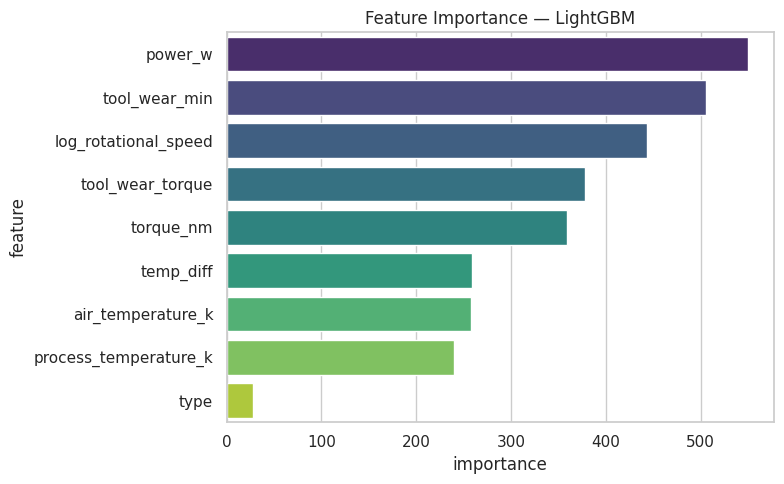

,feature,importance
7,power_w,550
4,tool_wear_min,506
5,log_rotational_speed,444
8,tool_wear_torque,378
3,torque_nm,359
6,temp_diff,259
1,air_temperature_k,258
2,process_temperature_k,240
0,type,28


In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
elif hasattr(best_model, 'coef_'):
    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': np.abs(best_model.coef_[0])
    }).sort_values('importance', ascending=False)
else:
    importance_df = None

if importance_df is not None:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Feature Importance — {winner_name}')
    plt.tight_layout()
    plt.show()
    display(importance_df)


## Final Production Model — Training di SEMUA Data (`X_train` + `X_test` digabung) dengan XGBoost

X_full: (10000, 9)
Distribusi target (full):
machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64
Model produksi (LightGBM) selesai dilatih di seluruh data (train+test).
Ingat: performa model ini TIDAK diukur lagi -> angka yang dilaporkan tetap dari `best_model` di Cell evaluasi final.


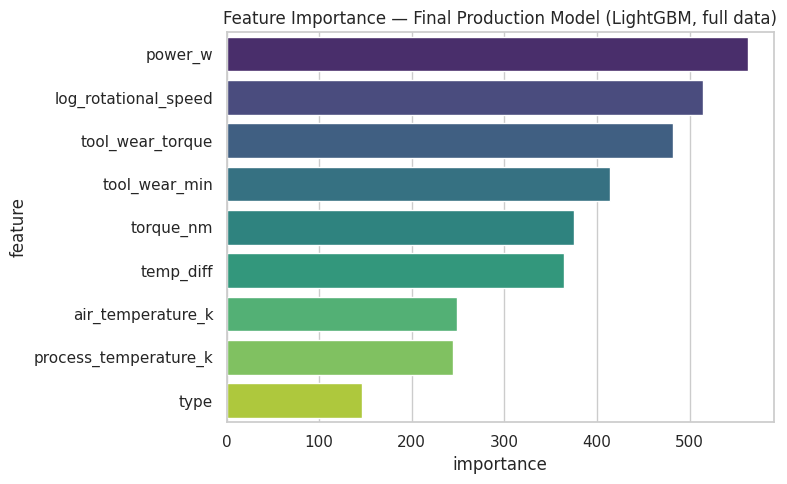

,feature,importance
7,power_w,563
5,log_rotational_speed,515
8,tool_wear_torque,482
4,tool_wear_min,414
3,torque_nm,375
6,temp_diff,364
1,air_temperature_k,249
2,process_temperature_k,245
0,type,146


In [ ]:
# Gabungkan X_train + X_test dan y_train + y_test jadi satu dataset penuh
X_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

print("X_full:", X_full.shape)
print("Distribusi target (full):")
print(y_full.value_counts(normalize=True).round(4) * 100)

# scale_pos_weight dihitung ulang dari seluruh data (train + test)
scale_pos_weight_full_data = (y_full == 0).sum() / (y_full == 1).sum()

# Hyperparameter terbaik dari model pemenang (hasil tuning di atas)
final_best_params = winner_info['params']

model_constructors_full = {
    'Logistic Regression': lambda: LogisticRegression(**final_best_params, class_weight='balanced',
                                                         max_iter=2000, random_state=RANDOM_STATE),
    'Random Forest': lambda: RandomForestClassifier(**final_best_params, class_weight='balanced_subsample',
                                                       random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': lambda: XGBClassifier(**final_best_params, scale_pos_weight=scale_pos_weight_full_data,
                                       eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1),
    'LightGBM': lambda: LGBMClassifier(**final_best_params, scale_pos_weight=scale_pos_weight_full_data,
                                         random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

final_production_model = model_constructors_full[winner_name]()

if winner_info['use_scaled']:
    scaler_production = StandardScaler()
    X_full_scaled = pd.DataFrame(scaler_production.fit_transform(X_full), columns=X_full.columns)
    final_production_model.fit(X_full_scaled, y_full)
else:
    final_production_model.fit(X_full, y_full)

print(f"Model produksi ({winner_name}) selesai dilatih di seluruh data (train+test).")
print("Ingat: performa model ini TIDAK diukur lagi -> angka yang dilaporkan tetap dari `best_model` di Cell evaluasi final.")

if hasattr(final_production_model, 'feature_importances_'):
    final_importance_df = pd.DataFrame({
        'feature': X_full.columns,
        'importance': final_production_model.feature_importances_
    }).sort_values('importance', ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=final_importance_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Feature Importance — Final Production Model ({winner_name}, full data)')
    plt.tight_layout()
    plt.show()
    display(final_importance_df)


## **SIMPAN MODEL**

In [ ]:
# Simpan model utama (untuk laporan — performanya sudah teruji jujur di X_test)
joblib.dump(best_model, 'models/best_model.pkl')
if winner_info['use_scaled']:
    joblib.dump(scaler_full, 'models/scaler.pkl')
joblib.dump(best_threshold, 'models/best_threshold.pkl')

print(f"Model ({winner_name}), scaler (jika perlu), dan threshold tersimpan di folder models/")

# Simpan model produksi (dilatih di semua data train+test — untuk deployment, BUKAN untuk klaim performa)
joblib.dump(final_production_model, 'models/final_production_model.pkl')
if winner_info['use_scaled']:
    joblib.dump(scaler_production, 'models/scaler_production.pkl')

print(f"Model produksi ({winner_name}, dilatih di semua data) tersimpan di models/final_production_model.pkl")